# Standard ML Training

**Goal:** Train classical ML classifiers (Logistic Regression, Random Forest, XGBoost) across multiple data splitting strategies to establish performance baselines.

**Input:** Prepared CSVs from `01_data_preparation.ipynb` (saved in `prepared_data/`).  
**Key feature:** ML dataset is used for standard ML training; TL dataset is used for temporal/graph-aware splits since it contains IP/timestamp columns.

## Configuration

All configurable settings for this notebook. Edit values before running.

In [14]:
from pydantic import BaseModel, Field
from typing import Optional


class MLDataConfig(BaseModel):
    """Data loading settings."""
    prepared_data_dir: str = Field(default="prepared_data", description="Directory with prepared CSVs")
    use_ml_dataset: bool = Field(default=True, description="True = ML dataset for random splits, False = TL dataset for all")
    use_correlation_features: bool = Field(default=True, description="Use correlation-selected feature subset")


class ModelHyperparamsConfig(BaseModel):
    """Hyperparameters for all models."""
    lr_max_iter: int = Field(default=1000, description="Logistic Regression max iterations")
    rf_n_estimators: int = Field(default=200, description="Random Forest number of trees")
    rf_max_depth: int = Field(default=16, description="Random Forest max depth")
    xgb_n_estimators: int = Field(default=200, description="XGBoost number of trees (standard sections)")
    xgb_n_estimators_es: int = Field(default=500, description="XGBoost max trees when early stopping is used")
    xgb_max_depth: int = Field(default=6, description="XGBoost max depth")
    xgb_learning_rate: float = Field(default=0.1, description="XGBoost learning rate")
    xgb_early_stopping_rounds: int = Field(default=20, description="XGBoost early stopping patience")


class SplitConfig(BaseModel):
    """Train/test split settings."""
    test_size: float = Field(default=0.3, description="Test set proportion for random splits")
    random_state: int = Field(default=42, description="Random seed for reproducibility")


class SectionsConfig(BaseModel):
    """Toggle which experiment sections to run."""
    run_multiclass: bool = Field(default=True, description="Multi-class")
    run_binary: bool = Field(default=True, description="Binary (BENIGN vs ATTACK)")
    run_balanced: bool = Field(default=True, description="Balanced binary (50/50)")
    run_temporal: bool = Field(default=False, description="Temporal split (CIC-style, requires Timestamp)")
    run_day_stratified: bool = Field(default=False, description="Day-stratified 70/30 (requires Timestamp)")
    run_chronological: bool = Field(default=False, description="Chronological 70/15/15 (requires Timestamp)")
    run_label_stratified: bool = Field(default=False, description="Per-label chronological 70/15/15 (requires Timestamp)")


data_cfg = MLDataConfig()
model_cfg = ModelHyperparamsConfig()
split_cfg = SplitConfig()
sections_cfg = SectionsConfig()

print("Configuration loaded:")
print(f"  Data: dir={data_cfg.prepared_data_dir}, use_ml={data_cfg.use_ml_dataset}, corr_features={data_cfg.use_correlation_features}")
print(f"  Split: test_size={split_cfg.test_size}, seed={split_cfg.random_state}")
print(f"  Sections: multiclass={sections_cfg.run_multiclass}, binary={sections_cfg.run_binary}, balanced={sections_cfg.run_balanced}")
print(f"            temporal={sections_cfg.run_temporal}, day_strat={sections_cfg.run_day_stratified}, chrono={sections_cfg.run_chronological}, label_strat={sections_cfg.run_label_stratified}")

Configuration loaded:
  Data: dir=prepared_data, use_ml=True, corr_features=True
  Split: test_size=0.3, seed=42
  Sections: multiclass=True, binary=True, balanced=True
            temporal=False, day_strat=False, chrono=False, label_strat=False


## Imports & Data Loading

In [15]:
import os
import json
import time
import datetime
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print("Base imports loaded.")

Base imports loaded.


In [16]:
try:
    from cuml.ensemble import RandomForestClassifier as cuRF
    from cuml.linear_model import LogisticRegression as cuLR
    import cupy as cp
    import xgboost as xgb
    CUML_AVAILABLE = True
    USE_GPU = True
    print("cuML + CuPy + XGBoost loaded — GPU acceleration available.")
except ImportError:
    import xgboost as xgb
    CUML_AVAILABLE = False
    USE_GPU = False
    print("cuML not available — falling back to CPU-only mode (XGBoost only).")

if USE_GPU:
    try:
        import ctypes
        nvrtc_dir = "/usr/local/lib/python3.11/dist-packages/nvidia/cuda_nvrtc/lib"
        if os.path.exists(nvrtc_dir):
            os.environ["LD_LIBRARY_PATH"] = nvrtc_dir + ":" + os.environ.get("LD_LIBRARY_PATH", "")
            ctypes.cdll.LoadLibrary(os.path.join(nvrtc_dir, "libnvrtc.so.12"))
            print("libnvrtc.so.12 loaded successfully.")
    except Exception:
        pass

cuML + CuPy + XGBoost loaded — GPU acceleration available.
libnvrtc.so.12 loaded successfully.


In [17]:
from pathlib import Path


def resolve_existing_path(path_str: str) -> Path:
    p = Path(path_str)
    if p.exists():
        return p

    cwd = Path.cwd()
    for base in [cwd, cwd.parent, cwd.parent.parent]:
        candidate = base / path_str
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Path not found: {path_str}")


def encode_categorical_features(df: pd.DataFrame, cols: list[str]) -> tuple[pd.DataFrame, dict[str, list[str]]]:
    out = df.copy()
    mappings = {}
    for col in cols:
        if col in out.columns and pd.api.types.is_object_dtype(out[col]):
            cat = out[col].astype("category")
            mappings[col] = cat.cat.categories.astype(str).tolist()
            out[col] = cat.cat.codes.astype(np.int32)
    return out, mappings


prepared_data_dir = resolve_existing_path(data_cfg.prepared_data_dir)
print(f"Using prepared_data_dir: {prepared_data_dir}")

meta_path = prepared_data_dir / 'metadata.json'
with open(meta_path, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

feature_cols = metadata['feature_cols']
label_mapping = metadata['label_mapping']

if data_cfg.use_correlation_features and 'selected_feature_cols' in metadata:
    active_feature_cols = metadata['selected_feature_cols']
    print(f"Using correlation-selected features: {len(active_feature_cols)}")
else:
    active_feature_cols = feature_cols
    if data_cfg.use_correlation_features:
        print("WARNING: use_correlation_features=True but no selected features in metadata. Using all features.")
    print(f"Using all features: {len(active_feature_cols)}")

ml_df = pd.read_csv(prepared_data_dir / 'ml_prepared.csv', low_memory=False)
print(f"ML dataset loaded: {ml_df.shape[0]:,} rows x {ml_df.shape[1]} cols")

tl_df = pd.read_csv(prepared_data_dir / 'tl_prepared.csv', low_memory=False)
print(f"TL dataset loaded: {tl_df.shape[0]:,} rows x {tl_df.shape[1]} cols")

# Encode any categorical feature columns to numeric codes for sklearn/cuML/XGBoost.
ml_df, ml_cat_maps = encode_categorical_features(ml_df, active_feature_cols)
tl_df, tl_cat_maps = encode_categorical_features(tl_df, active_feature_cols)
if ml_cat_maps:
    print(f"Encoded categorical ML features: {list(ml_cat_maps.keys())}")
if tl_cat_maps:
    print(f"Encoded categorical TL features: {list(tl_cat_maps.keys())}")

# Temporal sections are CIC-specific unless a timestamp column exists.
can_run_temporal = 'Timestamp' in tl_df.columns
if not can_run_temporal:
    print("Timestamp column not found in tl_prepared.csv. Temporal/day-based sections will be skipped.")

le = LabelEncoder()
le.classes_ = np.array(sorted(label_mapping.keys(), key=lambda x: label_mapping[x]))
class_names = le.classes_

Using prepared_data_dir: prepared_data
Using correlation-selected features: 37
ML dataset loaded: 257,673 rows x 46 cols
TL dataset loaded: 257,673 rows x 6 cols
Timestamp column not found in tl_prepared.csv. Temporal/day-based sections will be skipped.


In [18]:
# Helper: build classifiers dict for a section
def build_classifiers(binary=False, use_early_stopping=False):
    objective = 'binary:logistic' if binary else 'multi:softmax'
    n_est = model_cfg.xgb_n_estimators_es if use_early_stopping else model_cfg.xgb_n_estimators

    xgb_params = dict(
        n_estimators=n_est,
        max_depth=model_cfg.xgb_max_depth,
        learning_rate=model_cfg.xgb_learning_rate,
        objective=objective,
        tree_method='hist',
        device='cuda' if USE_GPU else 'cpu',
        random_state=split_cfg.random_state,
        verbosity=0,
    )
    if not binary:
        xgb_params['num_class'] = len(class_names)
    if use_early_stopping:
        xgb_params['early_stopping_rounds'] = model_cfg.xgb_early_stopping_rounds
        xgb_params['eval_metric'] = 'logloss'

    clfs = {}
    if CUML_AVAILABLE:
        clfs['Logistic Regression'] = cuLR(max_iter=model_cfg.lr_max_iter, solver='qn', verbose=0)
        clfs['Random Forest'] = cuRF(n_estimators=model_cfg.rf_n_estimators, max_depth=model_cfg.rf_max_depth, n_streams=1, random_state=split_cfg.random_state)
    clfs['XGBoost'] = xgb.XGBClassifier(**xgb_params)
    return clfs


def train_and_evaluate(classifiers, X_train, y_train, X_test, y_test,
                       X_train_scaled, X_test_scaled,
                       target_names, section_name,
                       X_val=None, y_val=None, X_val_scaled=None):
    results = {}
    trained_models = {}

    # Prepare GPU arrays
    if CUML_AVAILABLE:
        X_train_gpu = cp.asarray(X_train, dtype=cp.float32)
        X_test_gpu = cp.asarray(X_test, dtype=cp.float32)
        X_train_scaled_gpu = cp.asarray(X_train_scaled, dtype=cp.float32)
        X_test_scaled_gpu = cp.asarray(X_test_scaled, dtype=cp.float32)
        y_train_gpu = cp.asarray(y_train, dtype=cp.int32)
        if X_val is not None:
            X_val_gpu = cp.asarray(X_val, dtype=cp.float32)
            X_val_scaled_gpu = cp.asarray(X_val_scaled, dtype=cp.float32)

    for name, clf in classifiers.items():
        print(f"Training {name} [{'GPU' if USE_GPU else 'CPU'}]...")
        t0 = time.time()

        if name == 'Logistic Regression' and CUML_AVAILABLE:
            clf.fit(X_train_scaled_gpu, y_train_gpu)
            y_pred = cp.asnumpy(clf.predict(X_test_scaled_gpu)).astype(int)
            y_pred_val = cp.asnumpy(clf.predict(X_val_scaled_gpu)).astype(int) if X_val is not None else None
        elif name == 'Random Forest' and CUML_AVAILABLE:
            clf.fit(X_train_gpu, y_train_gpu)
            y_pred = cp.asnumpy(clf.predict(X_test_gpu)).astype(int)
            y_pred_val = cp.asnumpy(clf.predict(X_val_gpu)).astype(int) if X_val is not None else None
        else:  # XGBoost
            if X_val is not None and hasattr(clf, 'early_stopping_rounds') and clf.early_stopping_rounds:
                clf.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
                print(f"  XGBoost stopped at {clf.best_iteration} trees")
            else:
                clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)
            y_pred_val = clf.predict(X_val) if X_val is not None else None

        train_time = time.time() - t0

        acc = accuracy_score(y_test, y_pred)
        f1_w = f1_score(y_test, y_pred, average='weighted')
        f1_m = f1_score(y_test, y_pred, average='macro')

        res = {
            'accuracy': acc, 'f1_weighted': f1_w, 'f1_macro': f1_m,
            'train_time': train_time, 'y_pred': y_pred, 'device': 'GPU' if USE_GPU else 'CPU'
        }

        if y_pred_val is not None:
            res['val_accuracy'] = accuracy_score(y_val, y_pred_val)
            res['val_f1_macro'] = f1_score(y_val, y_pred_val, average='macro')
            res['y_pred_val'] = y_pred_val

        results[name] = res
        trained_models[name] = clf

        print(f"  Done in {train_time:.1f}s — Accuracy: {acc:.4f}, "
              f"Weighted F1: {f1_w:.4f}, Macro F1: {f1_m:.4f}\n")

    print(f"All {section_name} models trained.")
    return results, trained_models


def show_reports(results, y_test, target_names):
    for name, res in results.items():
        print(f"{'='*70}")
        print(f"Classification Report — {name}")
        print(f"{'='*70}")
        print(classification_report(y_test, res['y_pred'], target_names=target_names, digits=4, zero_division=0))
        print()


def show_confusion_matrices(results, y_test, target_names, title):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(8 * n, 7))
    if n == 1:
        axes = [axes]

    for idx, (name, res) in enumerate(results.items()):
        ax = axes[idx]
        cm = confusion_matrix(y_test, res['y_pred'])
        cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=target_names, yticklabels=target_names,
                    ax=ax, vmin=0, vmax=1, linewidths=0.3, cbar_kws={"shrink": 0.8})
        ax.set_title(f'{name}\nAcc={res["accuracy"]:.4f}  MacroF1={res["f1_macro"]:.4f}',
                     fontsize=11, fontweight='bold')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')
        ax.tick_params(axis='both', labelsize=7)

    plt.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


def show_feature_importance(trained_models, feature_cols, title_suffix=''):
    if 'XGBoost' not in trained_models:
        return
    clf = trained_models['XGBoost']
    importances = clf.feature_importances_
    feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
    top_20 = feat_imp.head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    top_20.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top 20 Features — XGBoost {title_suffix}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Feature Importance')
    ax.invert_yaxis()
    ax.tick_params(axis='y', labelsize=9)
    plt.tight_layout()
    plt.show()
    return feat_imp


def show_summary(results, target_names, title):
    rows = []
    for name, res in results.items():
        row = {
            'Model': name,
            'Device': res.get('device', 'CPU'),
            'Accuracy': f"{res['accuracy']:.4f}",
            'Weighted F1': f"{res['f1_weighted']:.4f}",
            'Macro F1': f"{res['f1_macro']:.4f}",
            'Train Time (s)': f"{res['train_time']:.1f}"
        }
        if 'val_accuracy' in res:
            row['Val Accuracy'] = f"{res['val_accuracy']:.4f}"
            row['Val Macro F1'] = f"{res['val_f1_macro']:.4f}"
        rows.append(row)

    summary_df = pd.DataFrame(rows)
    print(f"{title}\n")
    print(summary_df.to_string(index=False))
    return summary_df

---
## Multi-Class Classification Baseline

- **Dataset:** ML dataset
- **Split:** 70/30 stratified random (train/test)
- **Prediction:** Multi-class (15 attack types)
- **Balanced:** No (original class distribution)

In [19]:
if sections_cfg.run_multiclass:
    print("=" * 70)
    print("Multi-Class Classification Baseline")
    print("=" * 70)

    df_s8 = ml_df if data_cfg.use_ml_dataset else tl_df
    print(f"Using {'ML' if data_cfg.use_ml_dataset else 'TL'} dataset: {df_s8.shape[0]:,} rows")

    X = df_s8[active_feature_cols].values
    y = df_s8['label_encoded'].values

    print(f"Feature matrix: {X.shape}")
    print(f"Classes: {len(np.unique(y))}")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=split_cfg.test_size, random_state=split_cfg.random_state, stratify=y
    )
    print(f"Train: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}")

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    classifiers = build_classifiers(binary=False)
    results, trained_models = train_and_evaluate(
        classifiers, X_train, y_train, X_test, y_test,
        X_train_scaled, X_test_scaled, class_names, "multi-class"
    )
else:
    print("Multi-Class Classification Baseline DISABLED.")

Multi-Class Classification Baseline
Using ML dataset: 257,673 rows
Feature matrix: (257673, 37)
Classes: 10
Train: 180,371, Test: 77,302
Training Logistic Regression [GPU]...
  Done in 0.0s — Accuracy: 0.5610, Weighted F1: 0.4456, Macro F1: 0.1593

Training Random Forest [GPU]...
  Done in 2.9s — Accuracy: 0.8271, Weighted F1: 0.8039, Macro F1: 0.5283

Training XGBoost [GPU]...
  Done in 4.2s — Accuracy: 0.8315, Weighted F1: 0.8110, Macro F1: 0.5740

All multi-class models trained.


In [20]:
if sections_cfg.run_multiclass:
    show_reports(results, y_test, class_names)

Classification Report — Logistic Regression
                precision    recall  f1-score   support

      Analysis     0.0000    0.0000    0.0000       803
        BENIGN     0.5976    0.8901    0.7151     27900
      Backdoor     0.0000    0.0000    0.0000       699
           DoS     0.0000    0.0000    0.0000      4906
      Exploits     0.3244    0.0901    0.1411     13358
       Fuzzers     0.0548    0.0045    0.0084      7274
       Generic     0.5521    0.9763    0.7053     17661
Reconnaissance     0.2589    0.0122    0.0232      4196
     Shellcode     0.0000    0.0000    0.0000       453
         Worms     0.0000    0.0000    0.0000        52

      accuracy                         0.5610     77302
     macro avg     0.1788    0.1973    0.1593     77302
  weighted avg     0.4171    0.5610    0.4456     77302


Classification Report — Random Forest
                precision    recall  f1-score   support

      Analysis     0.9750    0.0486    0.0925       803
        BENIGN   

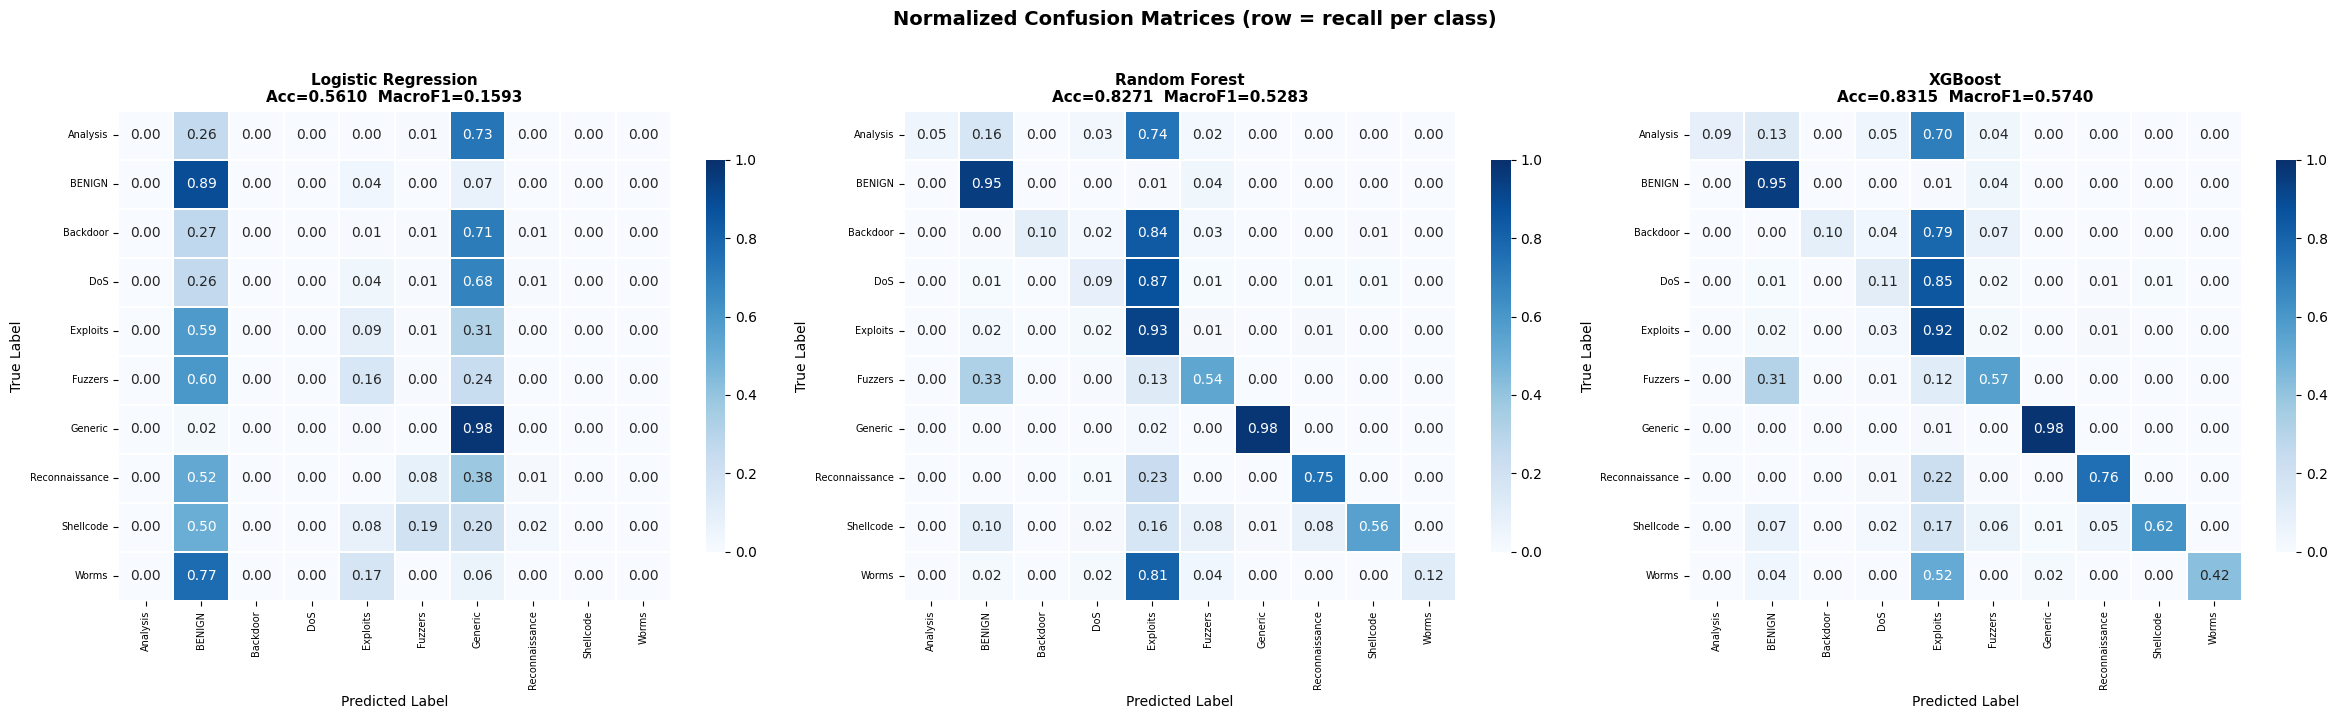

In [21]:
if sections_cfg.run_multiclass:
    show_confusion_matrices(results, y_test, class_names, 'Normalized Confusion Matrices (row = recall per class)')

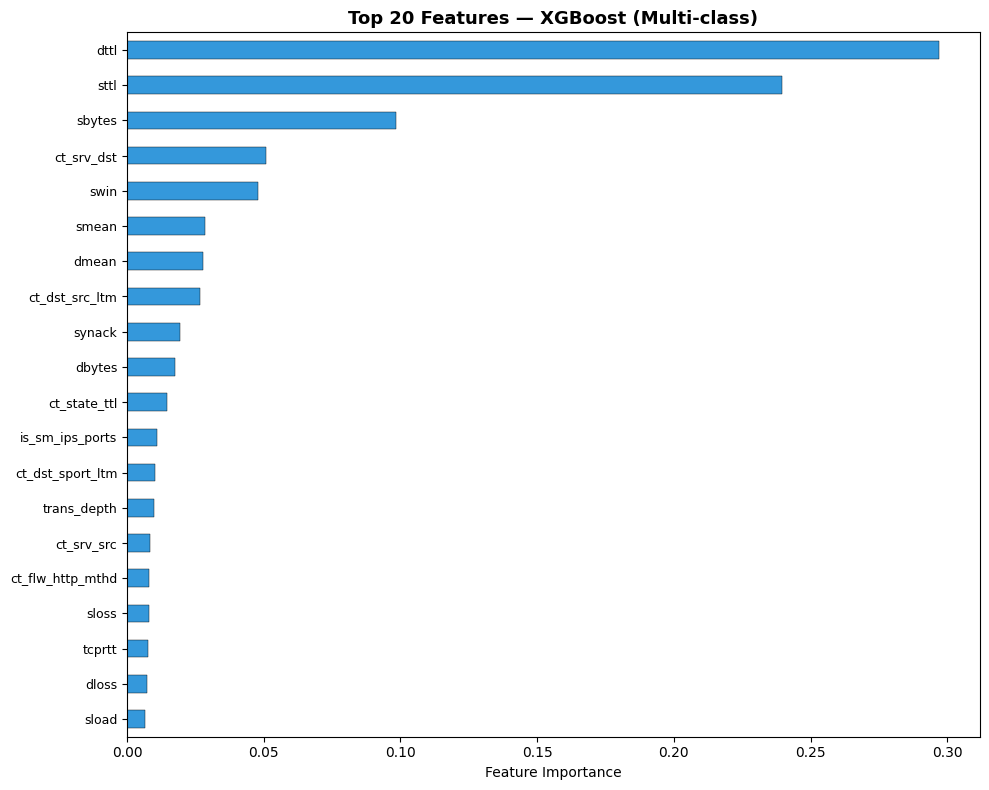

In [22]:
if sections_cfg.run_multiclass:
    show_feature_importance(trained_models, active_feature_cols, '(Multi-class)')

In [23]:
if sections_cfg.run_multiclass:
    s8_summary = show_summary(results, class_names, 'Standard ML Baseline — Summary')

    # Per-class F1
    print("\n\nPer-Class F1 Score Comparison\n")
    per_class_f1 = {}
    for name, res in results.items():
        report = classification_report(y_test, res['y_pred'], target_names=class_names, output_dict=True, zero_division=0)
        per_class_f1[name] = {cls: report[cls]['f1-score'] for cls in class_names}
    f1_df = pd.DataFrame(per_class_f1).round(4)
    f1_df['Best Model'] = f1_df.apply(lambda row: f1_df.columns[row.argmax()], axis=1)
    print(f1_df.to_string())

    weak_classes = f1_df[f1_df.drop(columns='Best Model').max(axis=1) < 0.5]
    if len(weak_classes) > 0:
        print(f"\nClasses where ALL models have F1 < 0.5:")
        for cls in weak_classes.index:
            best_f1 = f1_df.drop(columns='Best Model').loc[cls].max()
            print(f"  {cls}: best F1 = {best_f1:.4f}")

Standard ML Baseline — Summary

              Model Device Accuracy Weighted F1 Macro F1 Train Time (s)
Logistic Regression    GPU   0.5610      0.4456   0.1593            0.0
      Random Forest    GPU   0.8271      0.8039   0.5283            2.9
            XGBoost    GPU   0.8315      0.8110   0.5740            4.2


Per-Class F1 Score Comparison

                Logistic Regression  Random Forest  XGBoost     Best Model
Analysis                     0.0000         0.0925   0.1563        XGBoost
BENIGN                       0.7151         0.9240   0.9272        XGBoost
Backdoor                     0.0000         0.1767   0.1722  Random Forest
DoS                          0.0000         0.1464   0.1785        XGBoost
Exploits                     0.1411         0.7345   0.7372        XGBoost
Fuzzers                      0.0084         0.6147   0.6319        XGBoost
Generic                      0.7053         0.9869   0.9888        XGBoost
Reconnaissance               0.0232         0.8

---
## Binary Classification Baseline

- **Dataset:** ML dataset
- **Split:** 70/30 stratified random (train/test)
- **Prediction:** Binary (BENIGN vs ATTACK)
- **Balanced:** No (original class distribution)

In [24]:
if sections_cfg.run_binary:
    print("=" * 70)
    print("Binary Classification Baseline")
    print("=" * 70)

    df_s9 = ml_df if data_cfg.use_ml_dataset else tl_df
    y_bin = (df_s9['Label'] != 'BENIGN').astype(int).values
    X = df_s9[active_feature_cols].values
    bin_class_names = np.array(['BENIGN', 'ATTACK'])

    print(f"BENIGN: {(y_bin == 0).sum():,}, ATTACK: {(y_bin == 1).sum():,}")

    X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
        X, y_bin, test_size=split_cfg.test_size, random_state=split_cfg.random_state, stratify=y_bin
    )

    scaler_bin = RobustScaler()
    X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)
    X_test_bin_scaled = scaler_bin.transform(X_test_bin)

    bin_classifiers = build_classifiers(binary=True)
    bin_results, bin_trained_models = train_and_evaluate(
        bin_classifiers, X_train_bin, y_train_bin, X_test_bin, y_test_bin,
        X_train_bin_scaled, X_test_bin_scaled, bin_class_names, "binary"
    )
else:
    print("Binary Classification Baseline DISABLED.")

Binary Classification Baseline
BENIGN: 93,000, ATTACK: 164,673
Training Logistic Regression [GPU]...
  Done in 0.0s — Accuracy: 0.7469, Weighted F1: 0.7518, Macro F1: 0.7431

Training Random Forest [GPU]...
  Done in 2.3s — Accuracy: 0.9440, Weighted F1: 0.9441, Macro F1: 0.9395

Training XGBoost [GPU]...
  Done in 0.6s — Accuracy: 0.9458, Weighted F1: 0.9459, Macro F1: 0.9415

All binary models trained.


Classification Report — Logistic Regression
              precision    recall  f1-score   support

      BENIGN     0.6042    0.8662    0.7119     27900
      ATTACK     0.8999    0.6796    0.7744     49402

    accuracy                         0.7469     77302
   macro avg     0.7521    0.7729    0.7431     77302
weighted avg     0.7932    0.7469    0.7518     77302


Classification Report — Random Forest
              precision    recall  f1-score   support

      BENIGN     0.9170    0.9290    0.9230     27900
      ATTACK     0.9596    0.9525    0.9560     49402

    accuracy                         0.9440     77302
   macro avg     0.9383    0.9407    0.9395     77302
weighted avg     0.9442    0.9440    0.9441     77302


Classification Report — XGBoost
              precision    recall  f1-score   support

      BENIGN     0.9165    0.9348    0.9256     27900
      ATTACK     0.9628    0.9519    0.9573     49402

    accuracy                         0.9458     77302
   macro avg

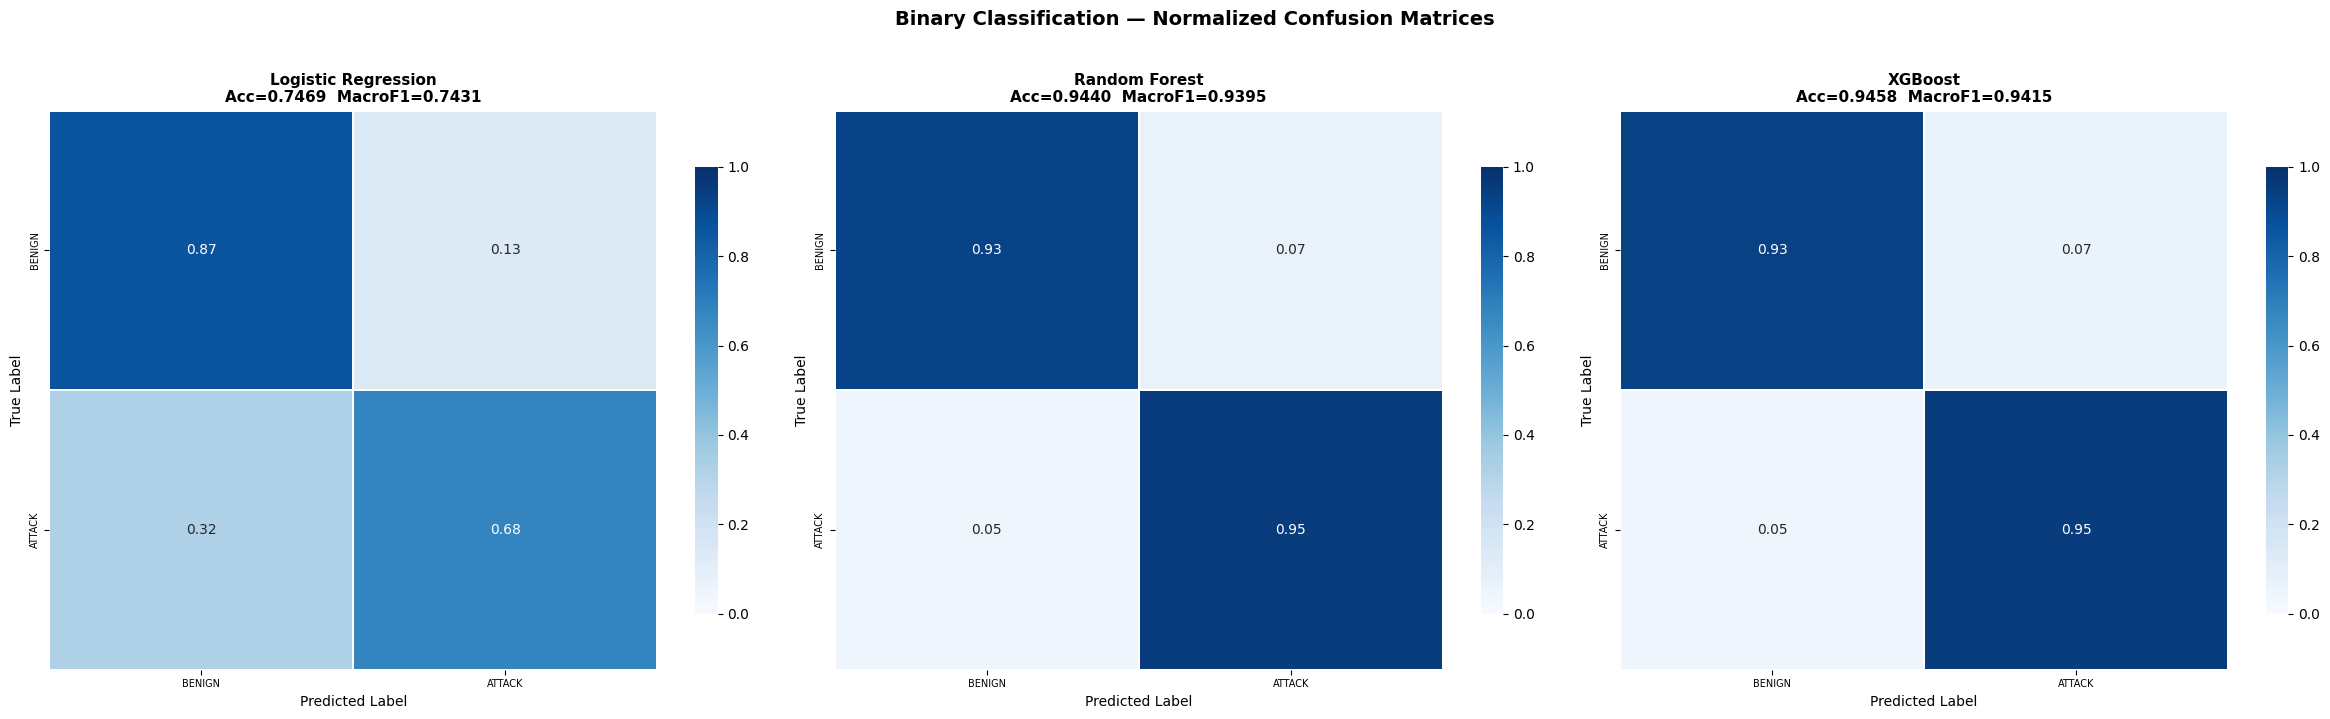

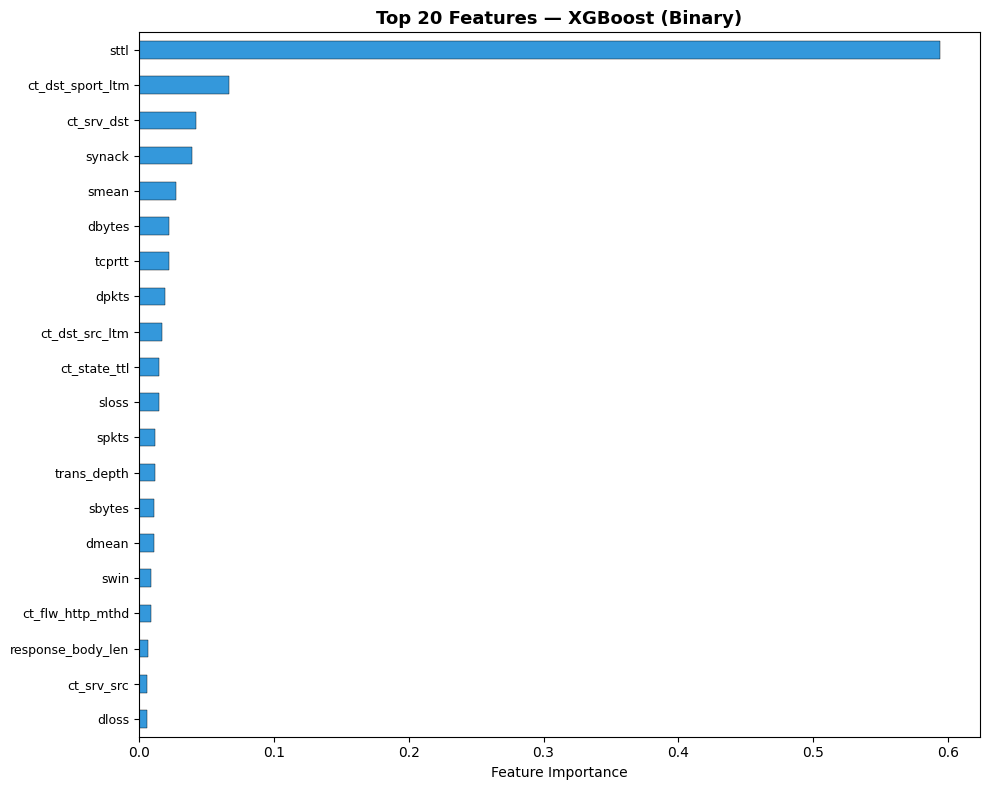

Binary Classification Baseline — Summary

              Model Device Accuracy Weighted F1 Macro F1 Train Time (s)
Logistic Regression    GPU   0.7469      0.7518   0.7431            0.0
      Random Forest    GPU   0.9440      0.9441   0.9395            2.3
            XGBoost    GPU   0.9458      0.9459   0.9415            0.6


In [25]:
if sections_cfg.run_binary:
    show_reports(bin_results, y_test_bin, bin_class_names)
    show_confusion_matrices(bin_results, y_test_bin, bin_class_names, 'Binary Classification — Normalized Confusion Matrices')
    show_feature_importance(bin_trained_models, active_feature_cols, '(Binary)')
    s9_summary = show_summary(bin_results, bin_class_names, 'Binary Classification Baseline — Summary')

---
## Balanced Binary Classification

- **Dataset:** ML dataset
- **Split:** 70/30 stratified random (train/test)
- **Prediction:** Binary (BENIGN vs ATTACK)
- **Balanced:** Yes — 50/50 BENIGN/ATTACK via undersampling

In [26]:
if sections_cfg.run_balanced:
    print("=" * 70)
    print("Balanced Binary Classification")
    print("=" * 70)

    df_s10 = ml_df if data_cfg.use_ml_dataset else tl_df
    df_s10 = df_s10.copy()
    df_s10['binary_label'] = (df_s10['Label'] != 'BENIGN').astype(int)

    attack_df = df_s10[df_s10['binary_label'] == 1]
    benign_df = df_s10[df_s10['binary_label'] == 0]

    n_attack = len(attack_df)
    n_benign = len(benign_df)
    n_min = min(n_attack, n_benign)
    if n_min == 0:
        raise ValueError("Balanced split requires both BENIGN and ATTACK samples.")

    benign_sampled = benign_df.sample(n=n_min, random_state=split_cfg.random_state)
    attack_sampled = attack_df.sample(n=n_min, random_state=split_cfg.random_state)
    balanced_df = pd.concat([benign_sampled, attack_sampled], ignore_index=True)

    print(f"Balanced: BENIGN={len(benign_sampled):,}, ATTACK={len(attack_sampled):,}, Total={len(balanced_df):,}")

    X_bal = balanced_df[active_feature_cols].values
    y_bal = balanced_df['binary_label'].values
    bal_class_names = np.array(['BENIGN', 'ATTACK'])

    X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
        X_bal, y_bal, test_size=split_cfg.test_size, random_state=split_cfg.random_state, stratify=y_bal
    )

    scaler_bal = RobustScaler()
    X_train_bal_scaled = scaler_bal.fit_transform(X_train_bal)
    X_test_bal_scaled = scaler_bal.transform(X_test_bal)

    bal_classifiers = build_classifiers(binary=True)
    bal_results, bal_trained_models = train_and_evaluate(
        bal_classifiers, X_train_bal, y_train_bal, X_test_bal, y_test_bal,
        X_train_bal_scaled, X_test_bal_scaled, bal_class_names, "balanced binary"
    )
else:
    print("Balanced Binary Classification DISABLED.")

Balanced Binary Classification
Balanced: BENIGN=93,000, ATTACK=93,000, Total=186,000
Training Logistic Regression [GPU]...
  Done in 0.0s — Accuracy: 0.7639, Weighted F1: 0.7614, Macro F1: 0.7614

Training Random Forest [GPU]...
  Done in 1.7s — Accuracy: 0.9442, Weighted F1: 0.9442, Macro F1: 0.9442

Training XGBoost [GPU]...
  Done in 0.5s — Accuracy: 0.9467, Weighted F1: 0.9467, Macro F1: 0.9467

All balanced binary models trained.


Classification Report — Logistic Regression
              precision    recall  f1-score   support

      BENIGN     0.7192    0.8658    0.7857     27900
      ATTACK     0.8315    0.6619    0.7370     27900

    accuracy                         0.7639     55800
   macro avg     0.7753    0.7639    0.7614     55800
weighted avg     0.7753    0.7639    0.7614     55800


Classification Report — Random Forest
              precision    recall  f1-score   support

      BENIGN     0.9256    0.9660    0.9454     27900
      ATTACK     0.9645    0.9224    0.9430     27900

    accuracy                         0.9442     55800
   macro avg     0.9451    0.9442    0.9442     55800
weighted avg     0.9451    0.9442    0.9442     55800


Classification Report — XGBoost
              precision    recall  f1-score   support

      BENIGN     0.9309    0.9651    0.9477     27900
      ATTACK     0.9638    0.9283    0.9457     27900

    accuracy                         0.9467     55800
   macro avg

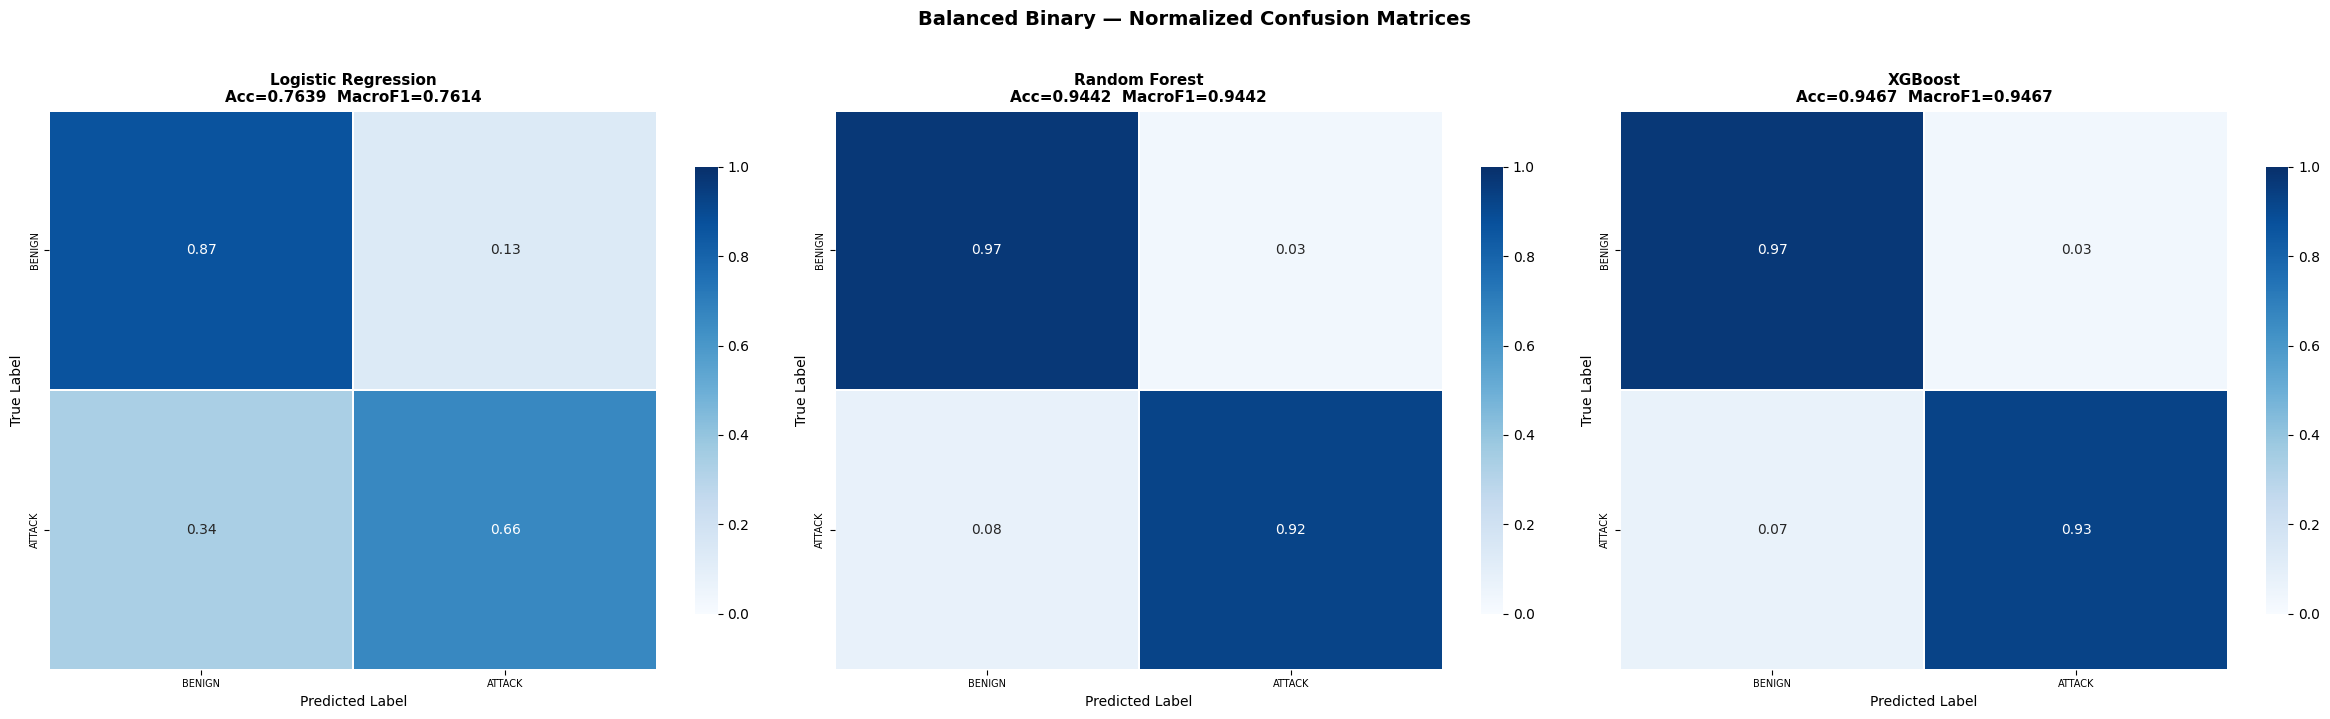

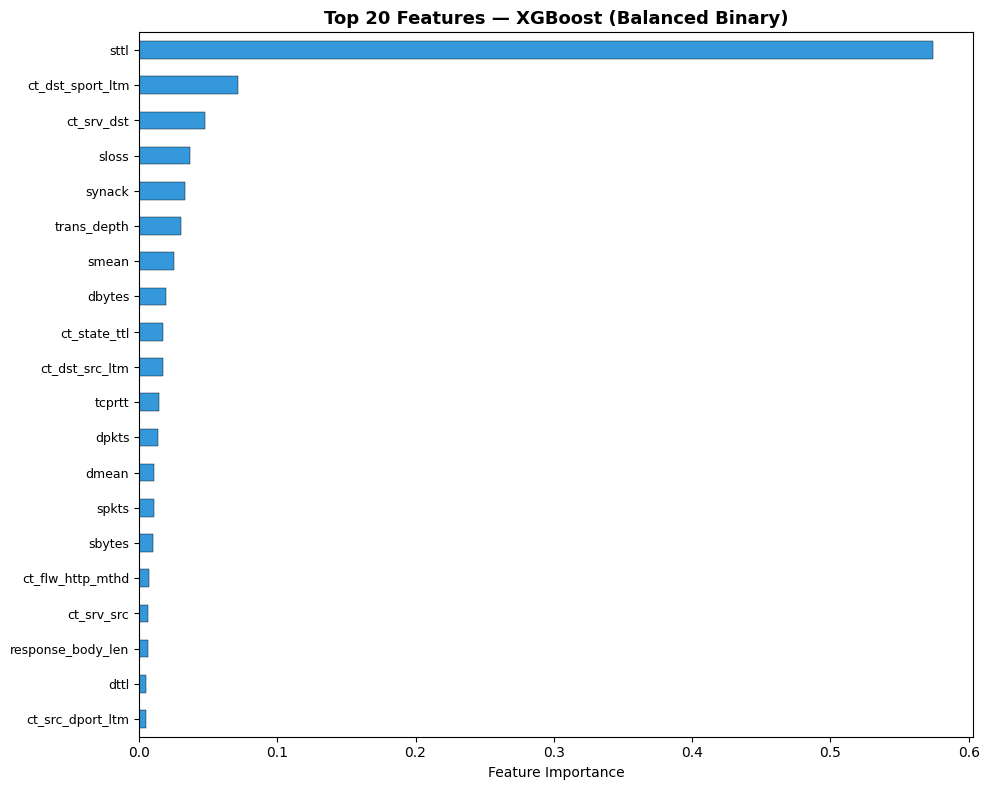

Balanced Binary Classification — Summary

              Model Device Accuracy Weighted F1 Macro F1 Train Time (s)
Logistic Regression    GPU   0.7639      0.7614   0.7614            0.0
      Random Forest    GPU   0.9442      0.9442   0.9442            1.7
            XGBoost    GPU   0.9467      0.9467   0.9467            0.5


In [27]:
if sections_cfg.run_balanced:
    show_reports(bal_results, y_test_bal, bal_class_names)
    show_confusion_matrices(bal_results, y_test_bal, bal_class_names, 'Balanced Binary — Normalized Confusion Matrices')
    show_feature_importance(bal_trained_models, active_feature_cols, '(Balanced Binary)')
    s10_summary = show_summary(bal_results, bal_class_names, 'Balanced Binary Classification — Summary')

---
## Temporal Split — Mon–Thu Train / Friday Test

- **Dataset:** TL dataset (requires timestamps)
- **Split:** Temporal — Mon–Thu train / Friday test
- **Prediction:** Binary (BENIGN vs ATTACK)
- **Balanced:** Yes — training set balanced via undersampling

In [28]:
if sections_cfg.run_temporal and can_run_temporal:
    print("=" * 70)
    print("Temporal Split (Mon-Thu / Friday)")
    print("=" * 70)

    # Parse timestamps and extract date
    tl_df['Timestamp_parsed'] = pd.to_datetime(tl_df['Timestamp'], format='mixed', dayfirst=True)
    tl_df['date'] = tl_df['Timestamp_parsed'].dt.date

    print(f"Timestamp range: {tl_df['Timestamp_parsed'].min()} -> {tl_df['Timestamp_parsed'].max()}")
    print("\nRows per day:")
    for d, n in tl_df.groupby('date').size().items():
        print(f"  {d} ({pd.Timestamp(d).strftime('%A')}): {n:,}")

    # Deduplicate on feature columns + label
    ts_dedup_cols = active_feature_cols + ['Label']
    ts_before = len(tl_df)
    tl_df_dedup = tl_df.drop_duplicates(subset=ts_dedup_cols, keep='first').copy()
    print(f"\nDeduplication: {ts_before:,} -> {len(tl_df_dedup):,}")

    tl_df_dedup['binary_label'] = (tl_df_dedup['Label'] != 'BENIGN').astype(int)

    # Split by day
    ts_train_mask = tl_df_dedup['date'] < datetime.date(2017, 7, 7)
    ts_test_mask = tl_df_dedup['date'] == datetime.date(2017, 7, 7)

    ts_train_full = tl_df_dedup[ts_train_mask]
    ts_test_full = tl_df_dedup[ts_test_mask]

    print(f"\nTrain (Mon-Thu): {len(ts_train_full):,} (ATTACK: {(ts_train_full['binary_label']==1).sum():,})")
    print(f"Test (Friday):   {len(ts_test_full):,} (ATTACK: {(ts_test_full['binary_label']==1).sum():,})")

    # Balance training set by undersampling the majority class
    ts_train_attack = ts_train_full[ts_train_full['binary_label'] == 1]
    ts_train_benign = ts_train_full[ts_train_full['binary_label'] == 0]
    ts_n_min = min(len(ts_train_attack), len(ts_train_benign))
    if ts_n_min == 0:
        raise ValueError("Temporal split requires both BENIGN and ATTACK samples in training set.")

    ts_train_benign_sampled = ts_train_benign.sample(n=ts_n_min, random_state=split_cfg.random_state)
    ts_train_attack_sampled = ts_train_attack.sample(n=ts_n_min, random_state=split_cfg.random_state)
    ts_train_balanced = pd.concat([ts_train_benign_sampled, ts_train_attack_sampled], ignore_index=True)

    print(f"Balanced train: {len(ts_train_balanced):,}")

    X_train_ts = ts_train_balanced[active_feature_cols].values
    y_train_ts = ts_train_balanced['binary_label'].values
    X_test_ts = ts_test_full[active_feature_cols].values
    y_test_ts = ts_test_full['binary_label'].values
    ts_class_names = np.array(['BENIGN', 'ATTACK'])

    scaler_ts = RobustScaler()
    X_train_ts_scaled = scaler_ts.fit_transform(X_train_ts)
    X_test_ts_scaled = scaler_ts.transform(X_test_ts)

    ts_classifiers = build_classifiers(binary=True)
    ts_results, ts_trained_models = train_and_evaluate(
        ts_classifiers, X_train_ts, y_train_ts, X_test_ts, y_test_ts,
        X_train_ts_scaled, X_test_ts_scaled, ts_class_names, "temporal-split"
    )
else:
    print("Temporal Split skipped (disabled or Timestamp column unavailable).")
    tl_df_dedup = None

Temporal Split skipped (disabled or Timestamp column unavailable).


In [29]:
if isinstance(globals().get('ts_results', None), dict) and len(ts_results) > 0:
    show_reports(ts_results, y_test_ts, ts_class_names)
    show_confusion_matrices(ts_results, y_test_ts, ts_class_names, 'Temporal Split — Normalized Confusion Matrices')
    show_feature_importance(ts_trained_models, active_feature_cols, '(Temporal Split)')
    s11_summary = show_summary(ts_results, ts_class_names, 'Temporal Split — Summary')

---
## Day-Stratified Split

- **Dataset:** TL dataset (requires timestamps)
- **Split:** 70/30 stratified per day (train/test)
- **Prediction:** Binary (BENIGN vs ATTACK)
- **Balanced:** Yes — training set balanced via undersampling

In [30]:
if sections_cfg.run_day_stratified and can_run_temporal:
    print("=" * 70)
    print("Day-Stratified Split")
    print("=" * 70)

    # Ensure tl_df_dedup exists
    if tl_df_dedup is None:
        tl_df['Timestamp_parsed'] = pd.to_datetime(tl_df['Timestamp'], format='mixed', dayfirst=True)
        tl_df['date'] = tl_df['Timestamp_parsed'].dt.date
        ts_dedup_cols = active_feature_cols + ['Label']
        tl_df_dedup = tl_df.drop_duplicates(subset=ts_dedup_cols, keep='first').copy()
        tl_df_dedup['binary_label'] = (tl_df_dedup['Label'] != 'BENIGN').astype(int)

    ds_train_parts, ds_test_parts = [], []

    print("Per-day stratified 70/30 split:\n")
    for day, day_df in tl_df_dedup.groupby('date'):
        day_name = pd.Timestamp(day).strftime('%A %b %d')
        n_benign = (day_df['binary_label'] == 0).sum()
        n_attack = (day_df['binary_label'] == 1).sum()

        if n_attack < 2 or n_benign < 2:
            ds_train_parts.append(day_df)
            print(f"  {day_name}: {len(day_df):>8,} rows -> all to train")
            continue

        day_train, day_test = train_test_split(
            day_df, test_size=split_cfg.test_size, random_state=split_cfg.random_state, stratify=day_df['binary_label']
        )
        ds_train_parts.append(day_train)
        ds_test_parts.append(day_test)
        print(f"  {day_name}: {len(day_df):>8,} rows -> train={len(day_train):,}, test={len(day_test):,}")

    ds_train_full = pd.concat(ds_train_parts, ignore_index=True)
    ds_test_full = pd.concat(ds_test_parts, ignore_index=True)

    # Balance training set by undersampling the majority class
    ds_train_attack = ds_train_full[ds_train_full['binary_label'] == 1]
    ds_train_benign = ds_train_full[ds_train_full['binary_label'] == 0]
    ds_n_min = min(len(ds_train_attack), len(ds_train_benign))
    if ds_n_min == 0:
        raise ValueError("Day-stratified split requires both BENIGN and ATTACK samples in training set.")

    ds_train_benign_sampled = ds_train_benign.sample(n=ds_n_min, random_state=split_cfg.random_state)
    ds_train_attack_sampled = ds_train_attack.sample(n=ds_n_min, random_state=split_cfg.random_state)
    ds_train_balanced = pd.concat([ds_train_benign_sampled, ds_train_attack_sampled], ignore_index=True)

    print(f"\nBalanced train: {len(ds_train_balanced):,}, Test: {len(ds_test_full):,}")

    X_train_ds = ds_train_balanced[active_feature_cols].values
    y_train_ds = ds_train_balanced['binary_label'].values
    X_test_ds = ds_test_full[active_feature_cols].values
    y_test_ds = ds_test_full['binary_label'].values
    ds_class_names = np.array(['BENIGN', 'ATTACK'])

    scaler_ds = RobustScaler()
    X_train_ds_scaled = scaler_ds.fit_transform(X_train_ds)
    X_test_ds_scaled = scaler_ds.transform(X_test_ds)

    ds_classifiers = build_classifiers(binary=True)
    ds_results, ds_trained_models = train_and_evaluate(
        ds_classifiers, X_train_ds, y_train_ds, X_test_ds, y_test_ds,
        X_train_ds_scaled, X_test_ds_scaled, ds_class_names, "day-stratified"
    )
else:
    print("Day-Stratified Split skipped (disabled or Timestamp column unavailable).")

Day-Stratified Split skipped (disabled or Timestamp column unavailable).


In [31]:
if isinstance(globals().get('ds_results', None), dict) and len(ds_results) > 0:
    show_reports(ds_results, y_test_ds, ds_class_names)
    show_confusion_matrices(ds_results, y_test_ds, ds_class_names, 'Day-Stratified Split — Normalized Confusion Matrices')
    show_feature_importance(ds_trained_models, active_feature_cols, '(Day-Stratified)')
    s12_summary = show_summary(ds_results, ds_class_names, 'Day-Stratified Split — Summary')

---
## Chronological Split

- **Dataset:** TL dataset (requires timestamps)
- **Split:** 70/15/15 chronological per day (train/val/test)
- **Prediction:** Binary (BENIGN vs ATTACK)
- **Balanced:** Yes — training set balanced via undersampling
- **Early stopping:** XGBoost uses validation set for early stopping

In [32]:
if sections_cfg.run_chronological and can_run_temporal:
    print("=" * 70)
    print("Chronological Split (70/15/15 per day)")
    print("=" * 70)

    if tl_df_dedup is None:
        tl_df['Timestamp_parsed'] = pd.to_datetime(tl_df['Timestamp'], format='mixed', dayfirst=True)
        tl_df['date'] = tl_df['Timestamp_parsed'].dt.date
        ts_dedup_cols = active_feature_cols + ['Label']
        tl_df_dedup = tl_df.drop_duplicates(subset=ts_dedup_cols, keep='first').copy()
        tl_df_dedup['binary_label'] = (tl_df_dedup['Label'] != 'BENIGN').astype(int)

    cs_train_parts, cs_val_parts, cs_test_parts = [], [], []

    print("Per-day chronological 70/15/15 split:\n")
    for day, day_df in tl_df_dedup.groupby('date'):
        day_name = pd.Timestamp(day).strftime('%A %b %d')
        day_sorted = day_df.sort_values('Timestamp_parsed').reset_index(drop=True)
        n = len(day_sorted)

        train_end = int(n * 0.70)
        val_end = int(n * 0.85)

        cs_day_train = day_sorted.iloc[:train_end]
        cs_day_val = day_sorted.iloc[train_end:val_end]
        cs_day_test = day_sorted.iloc[val_end:]

        cs_train_parts.append(cs_day_train)
        cs_val_parts.append(cs_day_val)
        cs_test_parts.append(cs_day_test)

        print(f"  {day_name}: {n:>8,} -> train={len(cs_day_train):,}, val={len(cs_day_val):,}, test={len(cs_day_test):,}")

    cs_train_full = pd.concat(cs_train_parts, ignore_index=True)
    cs_val_full = pd.concat(cs_val_parts, ignore_index=True)
    cs_test_full = pd.concat(cs_test_parts, ignore_index=True)

    # Balance training set by undersampling the majority class
    cs_train_attack = cs_train_full[cs_train_full['binary_label'] == 1]
    cs_train_benign = cs_train_full[cs_train_full['binary_label'] == 0]
    cs_n_min = min(len(cs_train_attack), len(cs_train_benign))
    if cs_n_min == 0:
        raise ValueError("Chronological split requires both BENIGN and ATTACK samples in training set.")

    cs_train_benign_sampled = cs_train_benign.sample(n=cs_n_min, random_state=split_cfg.random_state)
    cs_train_attack_sampled = cs_train_attack.sample(n=cs_n_min, random_state=split_cfg.random_state)
    cs_train_balanced = pd.concat([cs_train_benign_sampled, cs_train_attack_sampled], ignore_index=True)

    print(f"\nBalanced train: {len(cs_train_balanced):,}, Val: {len(cs_val_full):,}, Test: {len(cs_test_full):,}")

    X_train_cs = cs_train_balanced[active_feature_cols].values
    y_train_cs = cs_train_balanced['binary_label'].values
    X_val_cs = cs_val_full[active_feature_cols].values
    y_val_cs = cs_val_full['binary_label'].values
    X_test_cs = cs_test_full[active_feature_cols].values
    y_test_cs = cs_test_full['binary_label'].values
    cs_class_names = np.array(['BENIGN', 'ATTACK'])

    scaler_cs = RobustScaler()
    X_train_cs_scaled = scaler_cs.fit_transform(X_train_cs)
    X_val_cs_scaled = scaler_cs.transform(X_val_cs)
    X_test_cs_scaled = scaler_cs.transform(X_test_cs)

    cs_classifiers = build_classifiers(binary=True, use_early_stopping=True)
    cs_results, cs_trained_models = train_and_evaluate(
        cs_classifiers, X_train_cs, y_train_cs, X_test_cs, y_test_cs,
        X_train_cs_scaled, X_test_cs_scaled, cs_class_names, "chronological",
        X_val=X_val_cs, y_val=y_val_cs, X_val_scaled=X_val_cs_scaled
    )
else:
    print("Chronological Split skipped (disabled or Timestamp column unavailable).")

Chronological Split skipped (disabled or Timestamp column unavailable).


In [33]:
if isinstance(globals().get('cs_results', None), dict) and len(cs_results) > 0:
    show_reports(cs_results, y_test_cs, cs_class_names)
    show_confusion_matrices(cs_results, y_test_cs, cs_class_names, 'Chronological Split — Normalized Confusion Matrices (TEST)')
    show_feature_importance(cs_trained_models, active_feature_cols, '(Chronological)')
    s13_summary = show_summary(cs_results, cs_class_names, 'Chronological Split — Summary')

---
## Per-Label Stratified Chronological Split

- **Dataset:** TL dataset (requires timestamps)
- **Split:** 70/15/15 chronological per label (train/val/test)
- **Prediction:** Binary (BENIGN vs ATTACK)
- **Balanced:** Yes — training set balanced via undersampling
- **Early stopping:** XGBoost uses validation set for early stopping
- **Note:** Guarantees all 15 label classes appear in train, val, and test

In [34]:
if sections_cfg.run_label_stratified and can_run_temporal:
    print("=" * 70)
    print("Per-Label Stratified Chronological Split")
    print("=" * 70)

    if tl_df_dedup is None:
        tl_df['Timestamp_parsed'] = pd.to_datetime(tl_df['Timestamp'], format='mixed', dayfirst=True)
        tl_df['date'] = tl_df['Timestamp_parsed'].dt.date
        ts_dedup_cols = active_feature_cols + ['Label']
        tl_df_dedup = tl_df.drop_duplicates(subset=ts_dedup_cols, keep='first').copy()
        tl_df_dedup['binary_label'] = (tl_df_dedup['Label'] != 'BENIGN').astype(int)

    ls_train_parts, ls_val_parts, ls_test_parts = [], [], []

    print("Per-label chronological 70/15/15 split:\n")
    print(f"{'Label':<30} {'Total':>8} {'Train':>8} {'Val':>8} {'Test':>8}")
    print("-" * 80)

    for label in sorted(tl_df_dedup['Label'].unique()):
        label_df = tl_df_dedup[tl_df_dedup['Label'] == label]
        label_sorted = label_df.sort_values('Timestamp_parsed').reset_index(drop=True)
        n = len(label_sorted)

        train_end = int(n * 0.70)
        val_end = int(n * 0.85)

        ls_label_train = label_sorted.iloc[:train_end]
        ls_label_val = label_sorted.iloc[train_end:val_end]
        ls_label_test = label_sorted.iloc[val_end:]

        ls_train_parts.append(ls_label_train)
        ls_val_parts.append(ls_label_val)
        ls_test_parts.append(ls_label_test)

        print(f"  {label:<28} {n:>8,} {len(ls_label_train):>8,} {len(ls_label_val):>8,} {len(ls_label_test):>8,}")

    ls_train_full = pd.concat(ls_train_parts, ignore_index=True)
    ls_val_full = pd.concat(ls_val_parts, ignore_index=True)
    ls_test_full = pd.concat(ls_test_parts, ignore_index=True)

    print(f"\nTrain: {len(ls_train_full):,}, Val: {len(ls_val_full):,}, Test: {len(ls_test_full):,}")

    # Verify all attack types present
    ls_train_atypes = set(ls_train_full[ls_train_full['binary_label'] == 1]['Label'].unique())
    ls_val_atypes = set(ls_val_full[ls_val_full['binary_label'] == 1]['Label'].unique())
    ls_test_atypes = set(ls_test_full[ls_test_full['binary_label'] == 1]['Label'].unique())
    print(f"Attack types — train: {len(ls_train_atypes)}, val: {len(ls_val_atypes)}, test: {len(ls_test_atypes)}")

    # Balance training set by undersampling the majority class
    ls_train_attack = ls_train_full[ls_train_full['binary_label'] == 1]
    ls_train_benign = ls_train_full[ls_train_full['binary_label'] == 0]
    ls_n_min = min(len(ls_train_attack), len(ls_train_benign))
    if ls_n_min == 0:
        raise ValueError("Per-label chronological split requires both BENIGN and ATTACK samples in training set.")

    ls_train_benign_sampled = ls_train_benign.sample(n=ls_n_min, random_state=split_cfg.random_state)
    ls_train_attack_sampled = ls_train_attack.sample(n=ls_n_min, random_state=split_cfg.random_state)
    ls_train_balanced = pd.concat([ls_train_benign_sampled, ls_train_attack_sampled], ignore_index=True)

    print(f"Balanced train: {len(ls_train_balanced):,}")

    X_train_ls = ls_train_balanced[active_feature_cols].values
    y_train_ls = ls_train_balanced['binary_label'].values
    X_val_ls = ls_val_full[active_feature_cols].values
    y_val_ls = ls_val_full['binary_label'].values
    X_test_ls = ls_test_full[active_feature_cols].values
    y_test_ls = ls_test_full['binary_label'].values
    ls_class_names = np.array(['BENIGN', 'ATTACK'])

    scaler_ls = RobustScaler()
    X_train_ls_scaled = scaler_ls.fit_transform(X_train_ls)
    X_val_ls_scaled = scaler_ls.transform(X_val_ls)
    X_test_ls_scaled = scaler_ls.transform(X_test_ls)

    ls_classifiers = build_classifiers(binary=True, use_early_stopping=True)
    ls_results, ls_trained_models = train_and_evaluate(
        ls_classifiers, X_train_ls, y_train_ls, X_test_ls, y_test_ls,
        X_train_ls_scaled, X_test_ls_scaled, ls_class_names, "per-label chrono",
        X_val=X_val_ls, y_val=y_val_ls, X_val_scaled=X_val_ls_scaled
    )
else:
    print("Per-Label Stratified Chronological Split skipped (disabled or Timestamp column unavailable).")

Per-Label Stratified Chronological Split skipped (disabled or Timestamp column unavailable).


In [35]:
if isinstance(globals().get('ls_results', None), dict) and len(ls_results) > 0:
    show_reports(ls_results, y_test_ls, ls_class_names)
    show_confusion_matrices(ls_results, y_test_ls, ls_class_names, 'Per-Label Chrono Split — Normalized Confusion Matrices (TEST)')
    show_feature_importance(ls_trained_models, active_feature_cols, '(Per-Label Chrono)')
    s14_summary = show_summary(ls_results, ls_class_names, 'Per-Label Chrono Split — Summary')

    # Save XGBoost baseline results for reuse in 03_graph_ml.ipynb
    if 'XGBoost' in ls_results:
        xgb_res = ls_results['XGBoost']
        np.savez(
            os.path.join(data_cfg.prepared_data_dir, 'xgb_baseline_results.npz'),
            test_preds=xgb_res['y_pred'],
            accuracy=np.float64(xgb_res['accuracy']),
            f1_macro=np.float64(xgb_res['f1_macro']),
            f1_weighted=np.float64(xgb_res['f1_weighted']),
            train_time=np.float64(xgb_res['train_time']),
        )
        print(f"\nXGBoost baseline results saved to {data_cfg.prepared_data_dir}/xgb_baseline_results.npz")

---
## Cross-Section Comparison

In [36]:
print("=" * 80)
print("Cross-Section Comparison - XGBoost Test Metrics")
print("=" * 80)

cross_rows = []

all_sections = [
    ('Balanced Binary (Random)', 'bal_results'),
    ('Temporal (Mon-Thu/Fri)', 'ts_results'),
    ('Day-Stratified 70/30', 'ds_results'),
    ('Chronological 70/15/15', 'cs_results'),
    ('Per-Label Chrono 70/15/15', 'ls_results'),
]

for sec_name, results_var in all_sections:
    sec_res = globals().get(results_var, None)
    if isinstance(sec_res, dict) and 'XGBoost' in sec_res:
        m = sec_res['XGBoost']
        cross_rows.append({
            'Section': sec_name,
            'Accuracy': f"{m['accuracy']:.4f}",
            'Macro F1': f"{m['f1_macro']:.4f}",
            'Weighted F1': f"{m['f1_weighted']:.4f}",
        })

if cross_rows:
    cross_df = pd.DataFrame(cross_rows)
    print(cross_df.to_string(index=False))
else:
    print("No compatible section results found.")

Cross-Section Comparison - XGBoost Test Metrics
                 Section Accuracy Macro F1 Weighted F1
Balanced Binary (Random)   0.9467   0.9467      0.9467
